## Creating and training RC

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np


class ReservoirComputer: 
    
    def __init__(self, Nx, Nu, Ny,
                 alpha=0.9, spectral_radius=0.9, density=0.05,
                 ridge=1e-6, seed=None):                     
                                                            
        rng = np.random.default_rng(seed)                    #used to generate the internal random weights (Win, W, etc.) reproducibly.
        self.Nx, self.Nu, self.Ny = Nx, Nu, Ny               #Nx = number of neurons in reservoir, Nu = number of inputs, Ny = number of outputs
        self.alpha, self.ridge = alpha, ridge                #alpha = leak rate, ridge = lambda in ridge regression calculation
        self.Win = rng.uniform(-1, 1, size=(Nx, 1 + Nu))     #input weight matrix (including bias)
        W = rng.uniform(-1, 1, size=(Nx, Nx))                #recurrent weight matrix           
        W *= (rng.random((Nx, Nx)) < density)                #multiplying this boolean matrix by W to rescale to desired density
        eigmax = max(1e-12, np.max(np.abs(np.linalg.eigvals(W))))  #largest eigenvalue
        self.W = (spectral_radius / eigmax) * W              #largest eigenvalue of W will now be equal to the spectral radius specified by user
        self.Wout = None  

    def step(self, x, u):  #update step for x - given previous x and previous u, step function gives next x
        x_tilde = np.tanh(self.Win @ np.concatenate(([1.0], u)) + self.W @ x)
        return (1 - self.alpha) * x + self.alpha * x_tilde
                                       
    def run_reservoir(self, U, x0=None):            #applying the step function to all the input, collecting the feature vectors
        T = len(U)              
        X = np.zeros((T, self.Nx))                  #stores all reservoir states across time
        x = np.zeros(self.Nx) if x0 is None else x0 #current reservoir state at each step. 
        for t in range(T):
            x = self.step(x, U[t])                  #U[t] = input at time step t, allows for vectors
            X[t] = x                
        return X
                                             #note Ytarget is the output we want
    def train(self, U, Ytarget, washout=10): #training Wout by ridge regression adds a lambda||Wout||^2 term, penalises large weights and prevents overfitting
        X = self.run_reservoir(U)
        bias = np.ones((len(U), 1))          #vertical vector of 1s - T (=lenU) rows and 1 column
        Z = np.hstack([bias, U, X])          #stacking the features into an array, shape (T, 1+Nu+Nx)
        Z, Ytarget = Z[washout:], Ytarget[washout:] #getting rid of first washout steps, so reservoir can forget its initial 0 state
        I = np.eye(Z.shape[1])                      #identity matrix of size equal to the the number of columns of Z = 1+Nu+Nx
        self.Wout = np.linalg.solve(Z.T @ Z + self.ridge * I, Z.T @ Ytarget).T  #ridge formula
        return self

    def predict(self, U_test, K): #predict k steps after warmup sequence
        x0 = np.zeros(self.Nx) 
        X = self.run_reservoir(U_test, x0 = x0)
        bias = np.ones((len(U_test),1))
        Z = np.hstack([bias, U_test, X])
        Yhat = Z@self.Wout.T
        x_last = X[-1]
        y_last = Yhat[-1] #taking the final reservoir state and input from test sequence, to be used to start prediction loop
        Y_future = np.zeros((K,self.Ny))
        for k in range(K):
            x_next = self.step(x_last, y_last)
            z_next = np.hstack([1.0, y_last, x_next])
            y_next = z_next@ self.Wout.T
            Y_future[k] = y_next
            x_last = x_next
            y_last = y_next
        return Y_future 

    def autonomous_step(self, x_last, y_last): #the mapping from the previous reservoir state and output to the next reservoir state and output
        x_next = self.step(x_last, y_last)
        z = np.hstack([1.0, y_last, x_next])
        y_next = z@self.Wout.T
        return x_next, y_next

    def autonomous_run(self, x0, y0, n_steps): #given an initial x0 and y0, will run the reservoir for n_steps autonomously, returning X and Y
        X = np.zeros((n_steps, self.Nx))
        Y = np.zeros((n_steps, self.Ny))
        for i in range(n_steps):
            x,y = self.autonomous_step(x0, y0)
            X[i] = x
            Y[i] = y
            x0 = x
            y0 = y
        return X, Y
        

#train reservoir on the following training sequence - logistic map
r = 3.8 #control parameter, = 3.8 for chaotic behaviour
T = 300 #number of steps
s = np.zeros(T + 1) 
s[0] = 0.5  # initial condition
for n in range(1,T+1): #generate logistic map sequence
    s[n] = r * s[n-1] * (1 - s[n-1])
U = s[:-1][:,None] #rc expects 2D matrix with shape (T,Nu), meaning a column vector, with each row an input. But x is just a horizontal vector of values, so [:, None] turns it in to shape we need
Ytarget = s[1:][:,None] #similarly, changing from a horizontal vector to column vector to get shape (T,Ny) instead of (T,)
#training reservoir
rc = ReservoirComputer(Nx=400, Nu=1, Ny=1, alpha=0.8,
                           spectral_radius=0.9, density=0.05,
                           ridge=1e-6, seed=1)
rc.train(U=U, Ytarget=Ytarget)
        

## Attractor of $x_1$ vs $y$

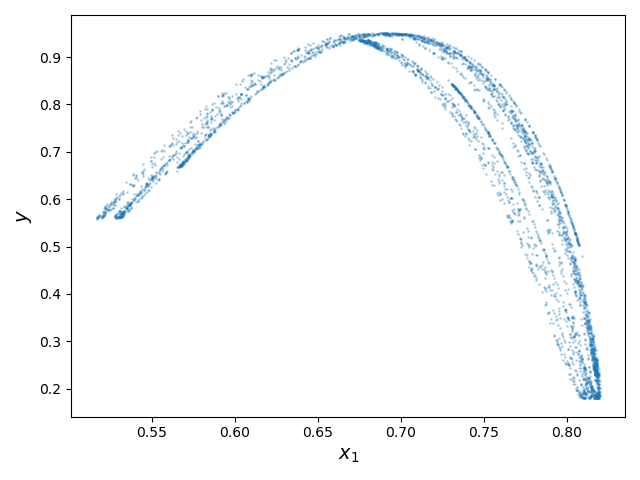

In [2]:
#plotting attractor when given no warm up sequence, just give rc an initial x,y 
x0 = np.zeros(rc.Nx)
y0 = np.array([0.6])
n_steps = 5000
X, Y = rc.autonomous_run(x0,y0,n_steps)
fig=plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X[1000:,0], Y[1000:,0], alpha=0.25, s=1)
ax.set_xlabel(r"$x_1$", fontsize = 14)
ax.set_ylabel(r"$y$", fontsize = 14)
plt.tight_layout()
plt.show()

## Comparing zero-state and warmed-up state initialization for different values of $y(0) 

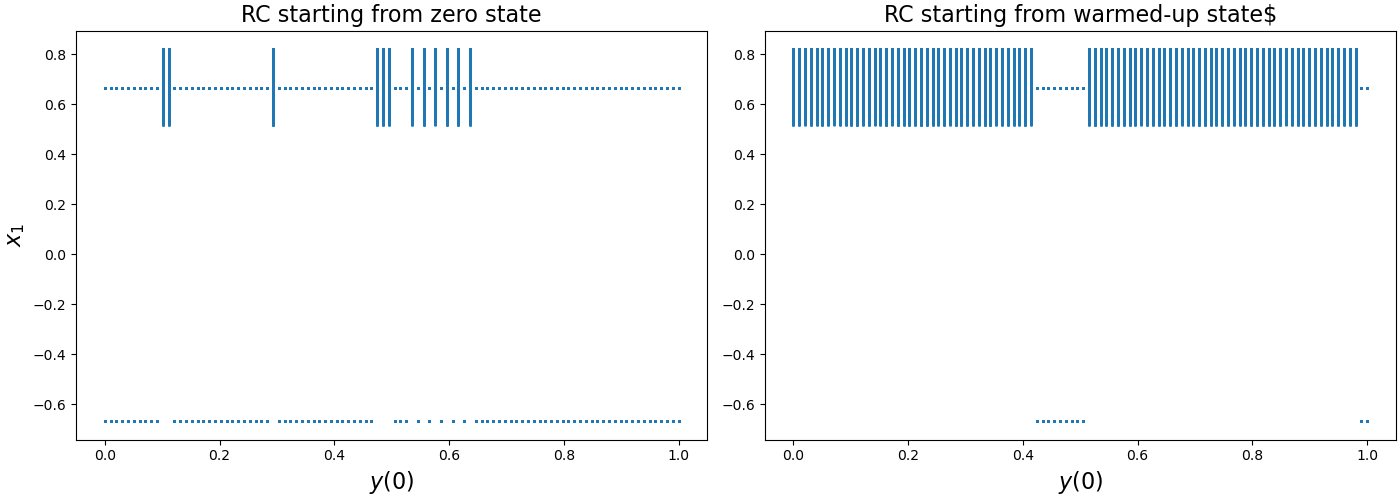

In [3]:
#comparing attractors from different initial states

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False, constrained_layout=True)

#Left: RC starting from zero state

x0_zero = np.zeros(rc.Nx)

n_y0 = 100
y0_grid = np.linspace(0.0, 1.0, n_y0)
n_steps = 5000
transient = 1000

y0_all, x_all = [], []
for y0 in y0_grid:
    y0_vec = np.array([y0])
    X, Y = rc.autonomous_run(x0_zero, y0_vec, n_steps)
    x = X[transient:, 0]
    y0_all.append(np.full(len(x), y0))
    x_all.append(x)

axes[0].scatter(np.concatenate(y0_all), np.concatenate(x_all), s=1, alpha=0.25)
axes[0].set_title(r"RC starting from zero state", fontsize=16)
axes[0].set_xlabel(r"$y(0)$", fontsize=16)
axes[0].set_ylabel(r"$x_1$", fontsize=16)


#Right: RC starting from warmed-up state

T_warmup = 40
s_warmup = np.zeros(T_warmup + 1)
rng = np.random.default_rng(5)
s_warmup[0] = rng.uniform(0, 1)
for i in range(1, len(s_warmup)):
    s_warmup[i] = r * s_warmup[i-1] * (1 - s_warmup[i-1])
U_warmup = s_warmup[:-1][:, None]
Y_warmup = s_warmup[1:][:, None]
x0_warm = rc.run_reservoir(U_warmup)[-1]
y0_warm = Y_warmup[-1]

y0_all, x_all = [], []
for y0 in y0_grid:
    y0_vec = np.array([y0])
    X, Y = rc.autonomous_run(x0_warm, y0_vec, n_steps)
    x = X[transient:, 0]
    y0_all.append(np.full(len(x), y0))
    x_all.append(x)

axes[1].scatter(np.concatenate(y0_all), np.concatenate(x_all), s=1, alpha=0.25)
axes[1].set_title(fr"RC starting from warmed-up state$", fontsize=16)
axes[1].set_xlabel(r"$y(0)$", fontsize=16)

plt.show()




## Basin of attraction plot

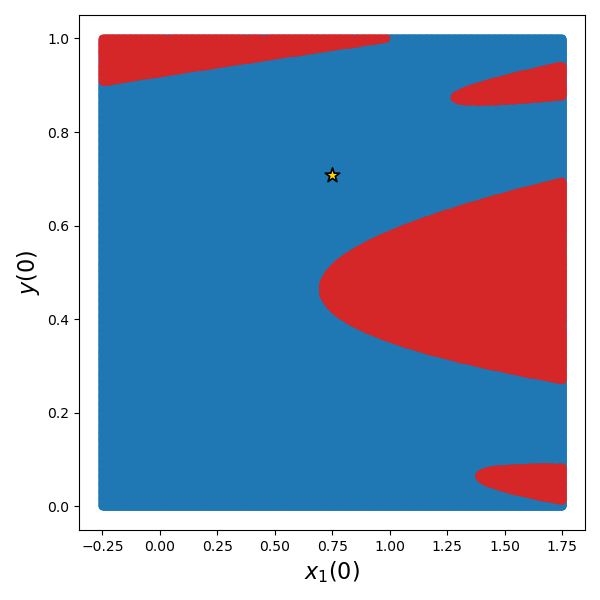

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved data
data = np.load("basins_data_1001.npz")
good = data["good"]
bad = data["bad"]
x0_warm = data["x0_warm"]
y0_warm = data["y0_warm"]

# Recreate plot
plt.figure(figsize=(6,6))
plt.scatter(good[:,0], good[:,1], s=20, c="tab:blue", marker="o", zorder=1)
plt.scatter(bad[:,0],  bad[:,1],  s=20, c="tab:red",  marker="o", zorder=2)
plt.scatter(x0_warm[0], y0_warm[0], s=120, c="gold",
            marker="*", edgecolors="black", linewidths=1.2, zorder=3)

plt.xlabel(r"$x_1(0)$", fontsize=16)   
plt.ylabel(r"$y(0)$", fontsize=16)

plt.tight_layout()
plt.savefig("basins_plot.png", dpi=600, bbox_inches="tight")
plt.show()

## Confabulated vs Learned Attractor

x0_warm[0] = 0.749545369060733
y0_warm    = [0.70731191]


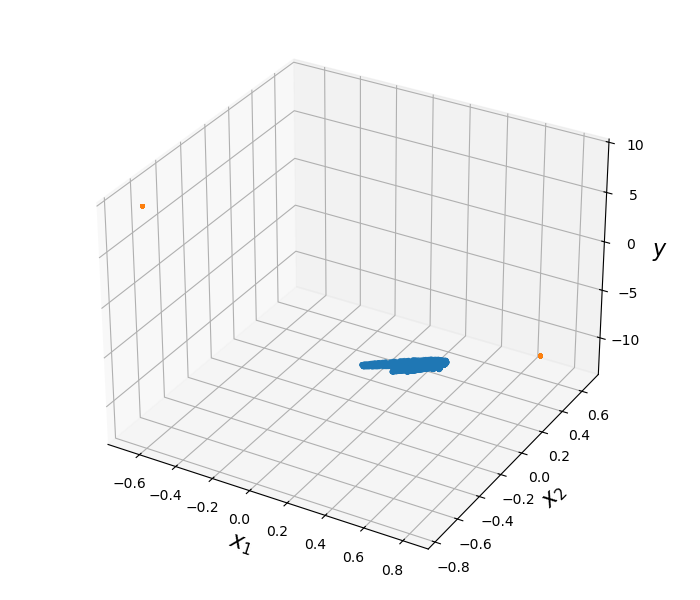

In [5]:
#bad vs good attractor X0,X1,y

#Warm-up to get a good initial (X0, y0)
r = 3.8
T_warmup = 40  
rng = np.random.default_rng(5)
s_warmup = np.zeros(T_warmup + 1)
s_warmup[0] = rng.uniform(0, 1)
for i in range(1, T_warmup + 1):
    s_warmup[i] = r * s_warmup[i-1] * (1 - s_warmup[i-1])
U_warmup = s_warmup[:-1][:, None]
Y_warmup = s_warmup[1:][:, None]
x0_warm = rc.run_reservoir(U_warmup)[-1] #run reservoir driven by warm-up input; take final state
y0_warm = Y_warmup[-1]   #warm-up-consistent initial output for autonomous run
print("x0_warm[0] =", x0_warm[0])
print("y0_warm    =", y0_warm)

#good: take warmed up state and output
x_good = x0_warm.copy()
y_good = y0_warm.copy()

# Bad: keep warmed-up template but override x[0] and y0 with a known bad combination
x_bad = x0_warm.copy()
x_bad[0] = 1.552
y_bad = np.array([0.394])

#run autonomous dynamics 
n_steps = 5000
transient = 1000

Xg, Yg = rc.autonomous_run(x_good, y_good, n_steps)
Xb, Yb = rc.autonomous_run(x_bad,  y_bad,  n_steps)

#3D plot: (X0, X1, y)
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(Xg[transient:,0], Xg[transient:,1], Yg[transient:,0], s=5, alpha = 0.5, label= fr"Chaotic (start: $x_1(0)={x_good[0]:.3f}$, $y(0)={y_good[0]:.3f}$)")
ax.scatter(Xb[transient:,0], Xb[transient:,1], Yb[transient:,0], s=5, alpha = 0.5, label= fr"Period-2 (start: $x_1(0)={x_bad[0]:.3f}$, $y(0)={y_bad[0]:.3f}$)")

ax.set_xlabel(r"$x_1$", fontsize = 16)
ax.set_ylabel(r"$x_2$", fontsize = 16)
ax.set_zlabel(r"$y$", fontsize = 16)
#ax.view_init(elev=20, azim=120) 
plt.tight_layout()
plt.show()